## Audio Processing Assignment

In [1]:
import librosa
import librosa.display

import numpy as np

import matplotlib.pyplot as plt

from scipy.fft import fft, fftfreq

In [2]:
audio_path = "./audio_sample.wav"

audio, sr = librosa.load(
    audio_path,
    sr=None
)

print("Sample Rate:", sr)
print("Duration (sec):", len(audio) / sr)

audio

c:\Users\Tejeswar Srinivasan\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample Rate: 44100
Duration (sec): 5.0


array([-0.01184082, -0.10336304, -0.14141846, ...,  0.06985474,
        0.04049683,  0.00274658], shape=(220500,), dtype=float32)

### waveform

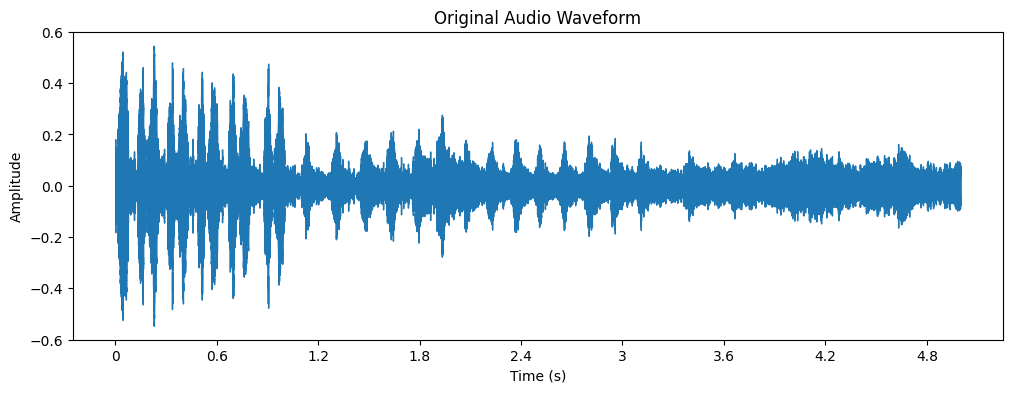

In [3]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Original Audio Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.show()

### Mel Spectrogram of Original Audio

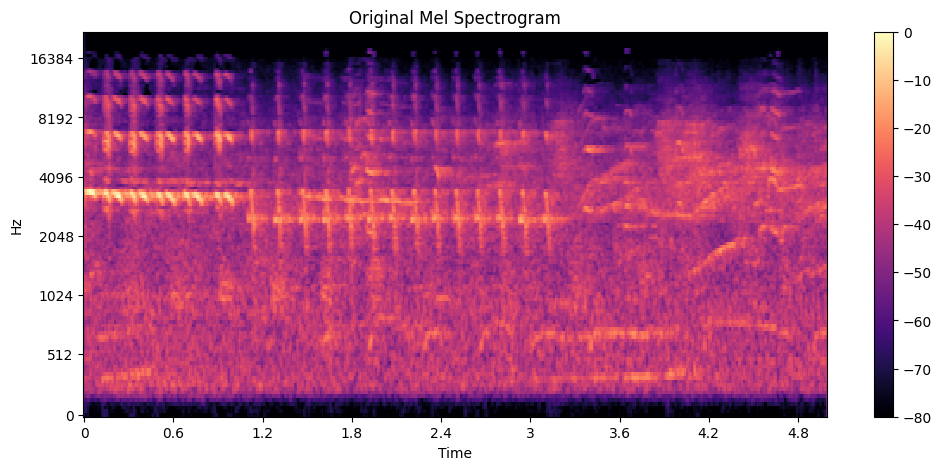

In [4]:
mel_spec = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()
plt.title("Original Mel Spectrogram")

plt.show()

### MFCC Heatmap of Original Audio

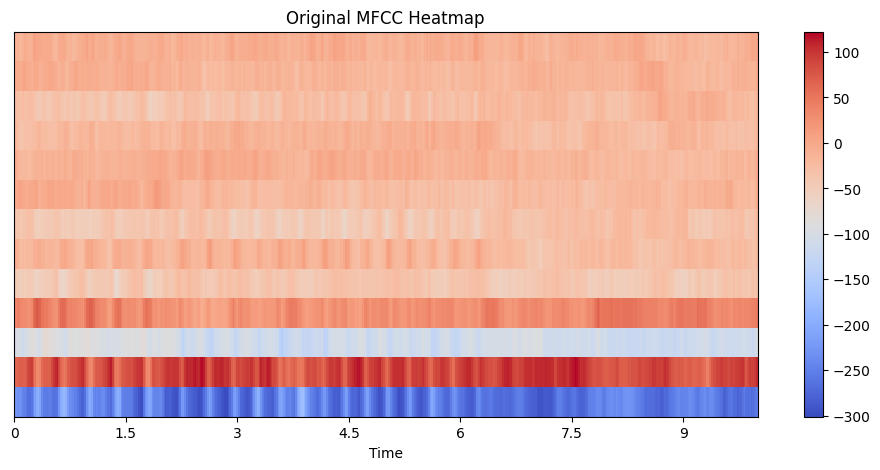

In [5]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    x_axis="time"
)

plt.colorbar()

plt.title("Original MFCC Heatmap")

plt.show()

### FFT Spectrum of Original Audio

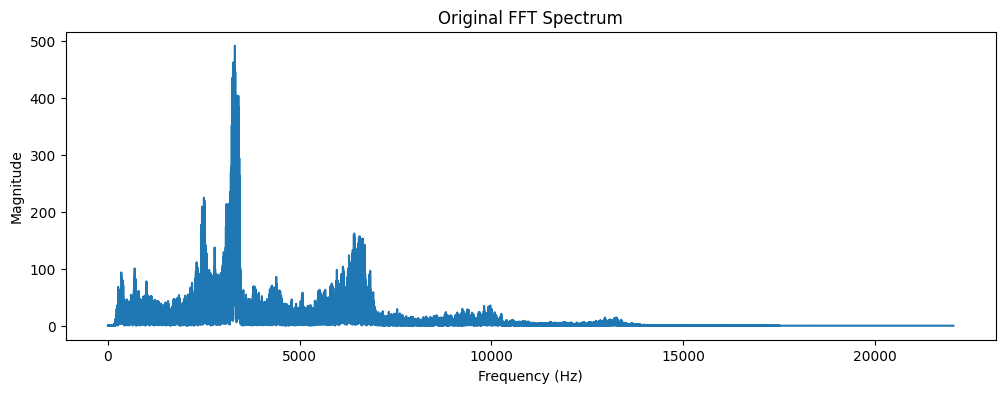

In [6]:
N = len(audio)

fft_values = fft(audio)

freqs = fftfreq(
    N,
    1/sr
)

positive = freqs >= 0

plt.figure(figsize=(12,4))

plt.plot(
    freqs[positive],
    np.abs(fft_values[positive])
)

plt.title("Original FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.show()

### Preprocessing

In [7]:
audio_resampled = librosa.resample(
    audio,
    orig_sr=sr,
    target_sr=8000
)

audio_normalized = librosa.util.normalize(
    audio_resampled
)

audio_trimmed, _ = librosa.effects.trim(
    audio_normalized,
    top_db=20
)

processed_sr = 8000

print("Original Length:", len(audio))
print("Processed Length:", len(audio_trimmed))

Original Length: 220500
Processed Length: 40000


### Compare Original vs Processed Waveform

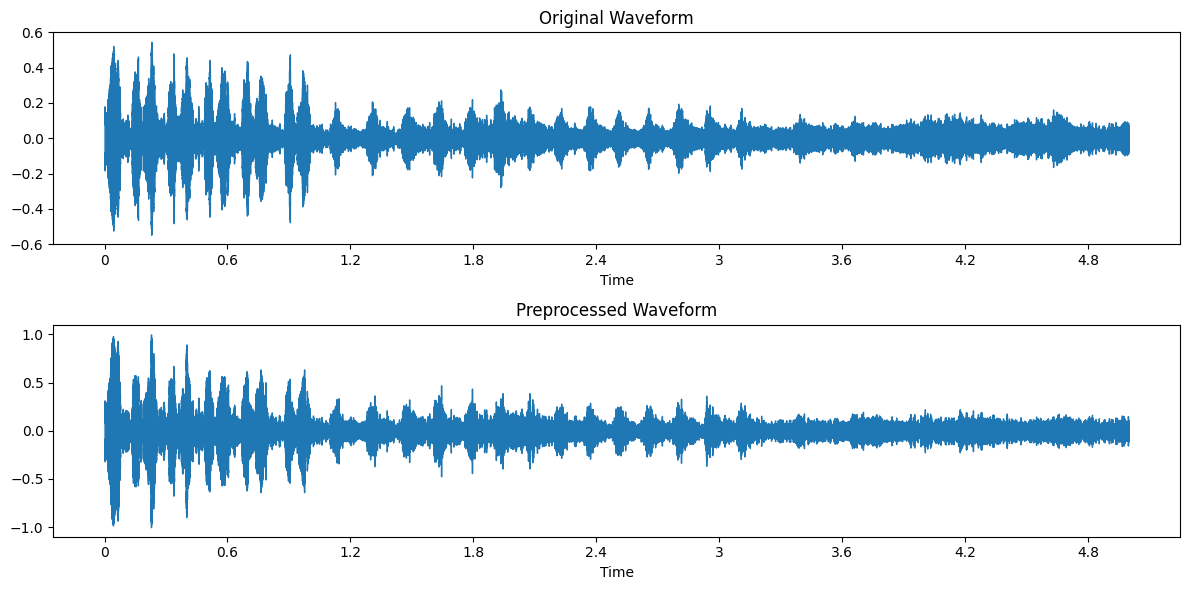

In [8]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(12,6)
)

librosa.display.waveshow(
    audio,
    sr=sr,
    ax=ax[0]
)

ax[0].set_title(
    "Original Waveform"
)

librosa.display.waveshow(
    audio_trimmed,
    sr=processed_sr,
    ax=ax[1]
)

ax[1].set_title(
    "Preprocessed Waveform"
)

plt.tight_layout()

plt.show()

### Preprocessed Mel Spectrogram

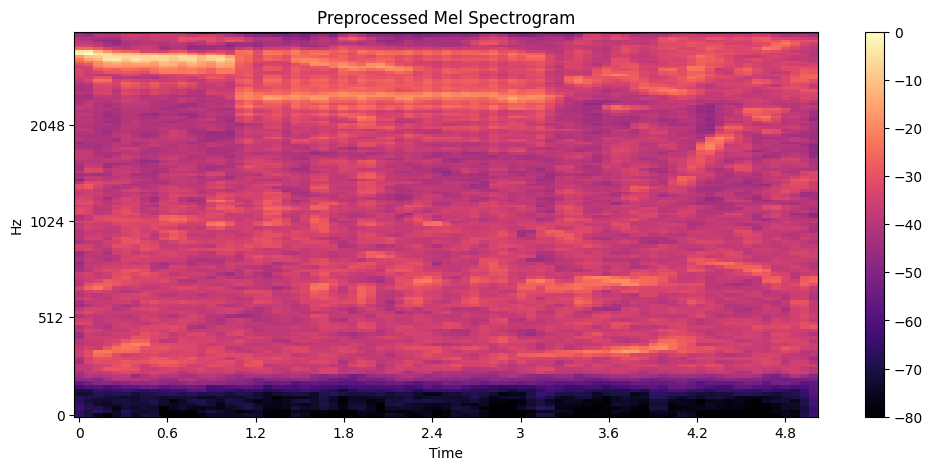

In [9]:
mel_processed = librosa.feature.melspectrogram(
    y=audio_trimmed,
    sr=processed_sr
)

mel_processed_db = librosa.power_to_db(
    mel_processed,
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_processed_db,
    sr=processed_sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title(
    "Preprocessed Mel Spectrogram"
)

plt.show()

### Preprocessed MFCC

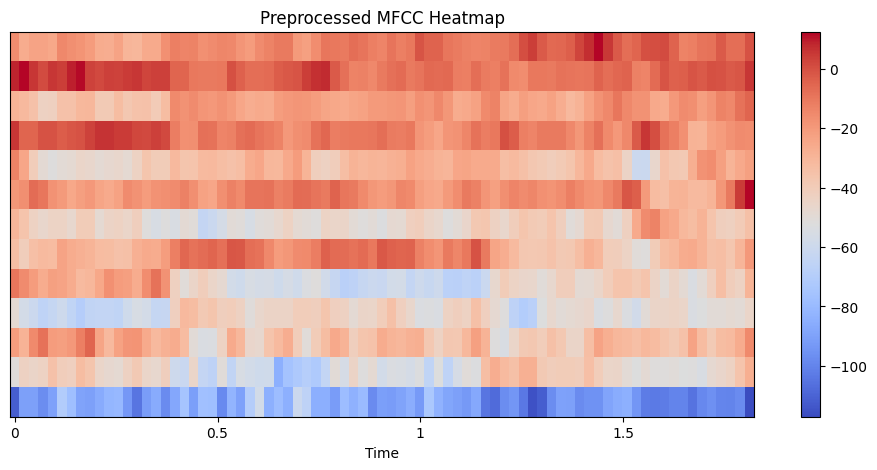

In [10]:
mfcc_processed = librosa.feature.mfcc(
    y=audio_trimmed,
    sr=processed_sr,
    n_mfcc=13
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc_processed,
    x_axis="time"
)

plt.colorbar()

plt.title(
    "Preprocessed MFCC Heatmap"
)

plt.show()

### Preprocessed FFT

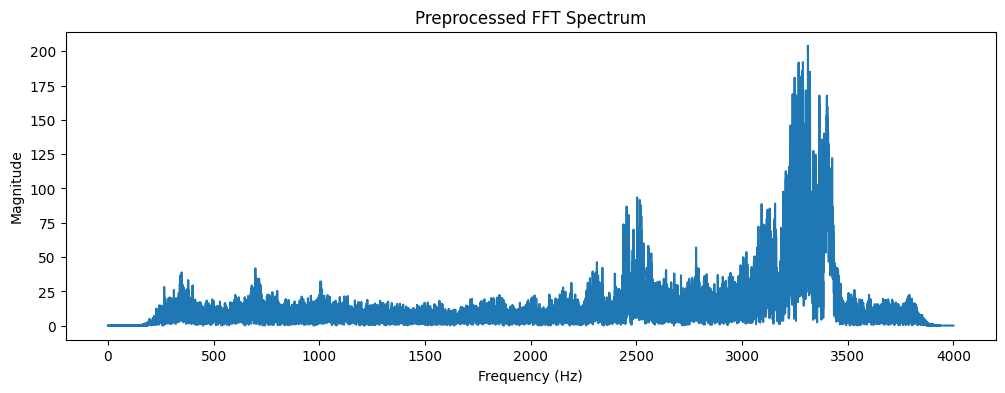

In [11]:
N = len(audio_trimmed)

fft_values = fft(audio_trimmed)

freqs = fftfreq(
    N,
    1/processed_sr
)

positive = freqs >= 0

plt.figure(figsize=(12,4))

plt.plot(
    freqs[positive],
    np.abs(
        fft_values[positive]
    )
)

plt.title(
    "Preprocessed FFT Spectrum"
)

plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Magnitude"
)

plt.show()

### Side-by-Side Mel Spectrogram Comparison

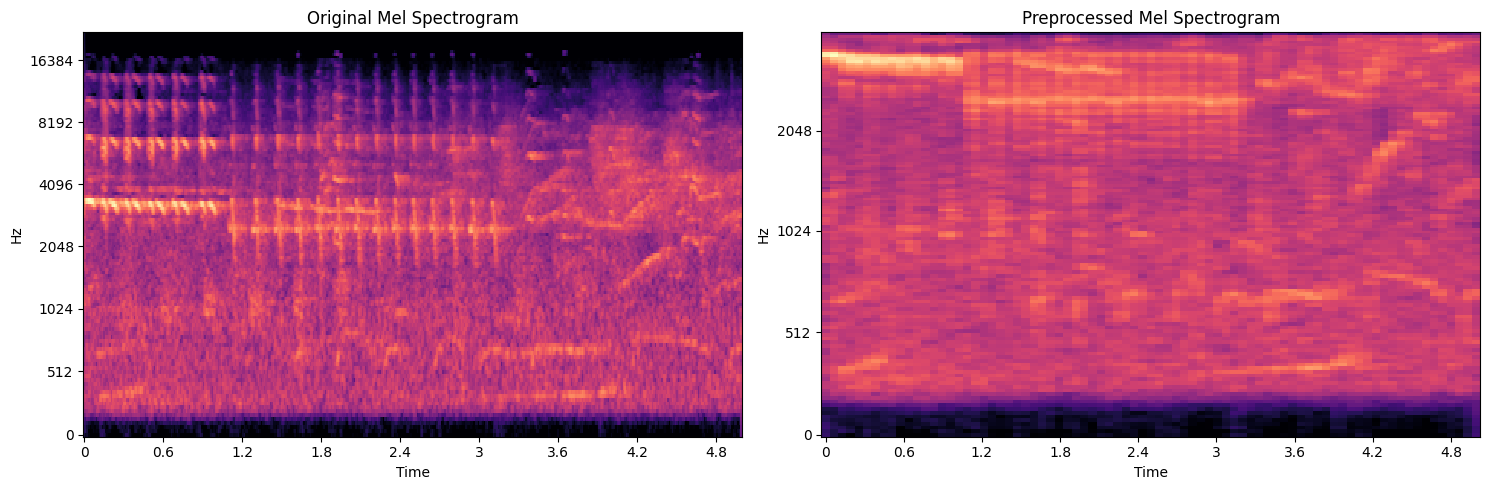

In [12]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(15,5)
)

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
    ax=ax[0]
)

ax[0].set_title(
    "Original Mel Spectrogram"
)

librosa.display.specshow(
    mel_processed_db,
    sr=processed_sr,
    x_axis="time",
    y_axis="mel",
    ax=ax[1]
)

ax[1].set_title(
    "Preprocessed Mel Spectrogram"
)

plt.tight_layout()

plt.show()